# Heart Disease Prediction — Model Comparison & Export

**Objective:** Compare Logistic Regression vs Random Forest on heart disease dataset, select the best model, and export it for REST API deployment.

**Dataset:** 1025 patients, 14 features, target = presence of heart disease

## 1. Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [28]:
df = pd.read_csv("heart.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1025 rows, 14 columns


In [29]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [31]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Column Dictionary:**
| Column | Description |
|---|---|
| age | Patient's age in years |
| sex | Gender (1=Male, 0=Female) |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar >120 (1=Yes, 0=No) |
| restecg | Resting ECG result (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=Yes, 0=No) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment (0-2) |
| ca | Number of major vessels (0-4) |
| thal | Thalassemia test result (0-3) |
| target | Heart disease present (1=Yes, 0=No) |

## 3. Exploratory Data Analysis

In [32]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nAfter removing duplicates:")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape: {df.shape}")

Missing values: 0
Duplicate rows: 723

After removing duplicates:
Shape: (302, 14)


### 3.1 Target Distribution

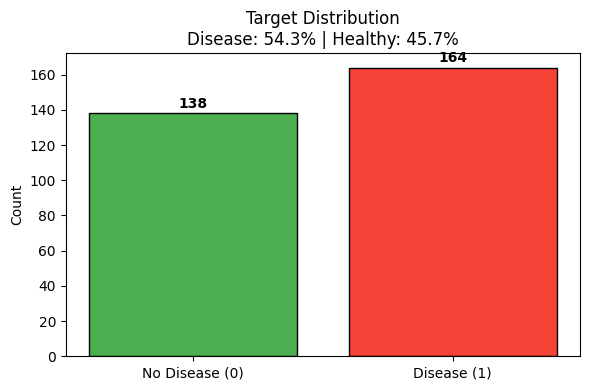

Dataset is balanced (54.3% disease cases).


In [33]:
plt.figure(figsize=(6, 4))
counts = df['target'].value_counts().sort_index()
bars = plt.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(count), ha='center', fontweight='bold')
pct = (counts[1] / len(df) * 100)
plt.title(f'Target Distribution\nDisease: {pct:.1f}% | Healthy: {100-pct:.1f}%')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Dataset is {'balanced' if 40 <= pct <= 60 else 'imbalanced'} ({pct:.1f}% disease cases).")

### 3.2 Numerical Features vs Target

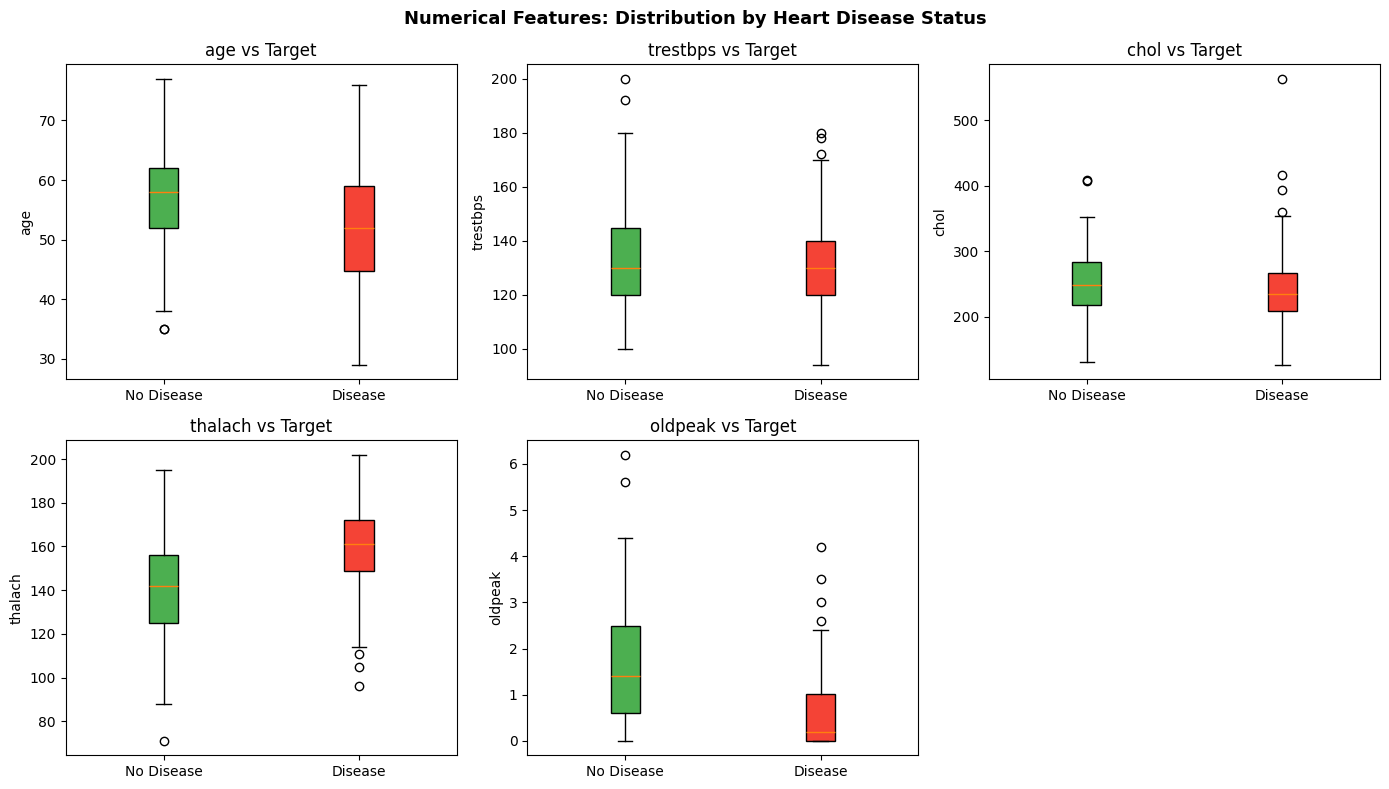

Insight:
  - age: Disease group has lower average (52.6 vs 56.6).
  - trestbps: Disease group has lower average (129.2 vs 134.4).
  - chol: Disease group has lower average (242.6 vs 251.1).
  - thalach: Disease group has higher average (158.4 vs 139.1).
  - oldpeak: Disease group has lower average (0.6 vs 1.6).


In [34]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data_0 = df[df['target']==0][col]
    data_1 = df[df['target']==1][col]
    bp = ax.boxplot([data_0, data_1], labels=['No Disease', 'Disease'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(f'{col} vs Target')
    ax.set_ylabel(col)

axes[5].axis('off')
plt.suptitle('Numerical Features: Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
for col in num_cols:
    m0 = df[df['target']==0][col].mean()
    m1 = df[df['target']==1][col].mean()
    direction = "higher" if m1 > m0 else "lower"
    print(f"  - {col}: Disease group has {direction} average ({m1:.1f} vs {m0:.1f}).")

### 3.3 Numerical Feature Distributions

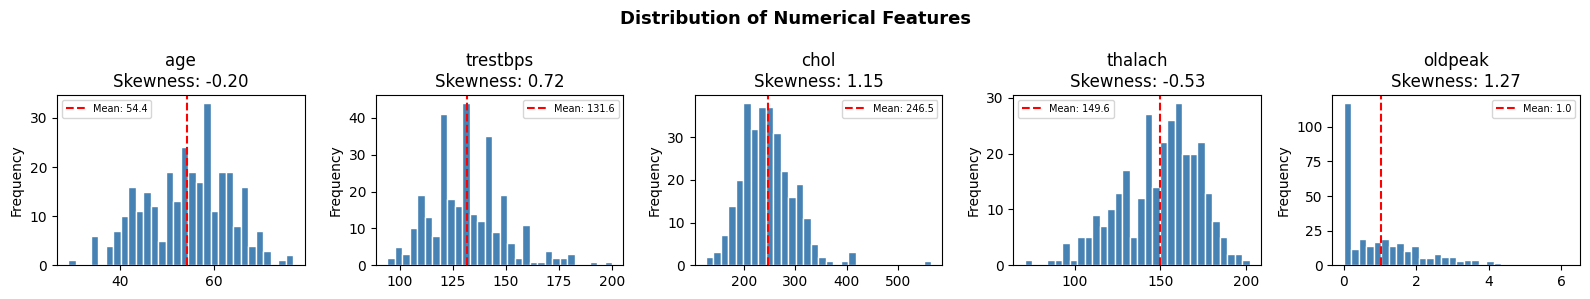

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i, col in enumerate(num_cols):
    skew = df[col].skew()
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'{col}\nSkewness: {skew:.2f}')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Categorical Features vs Target

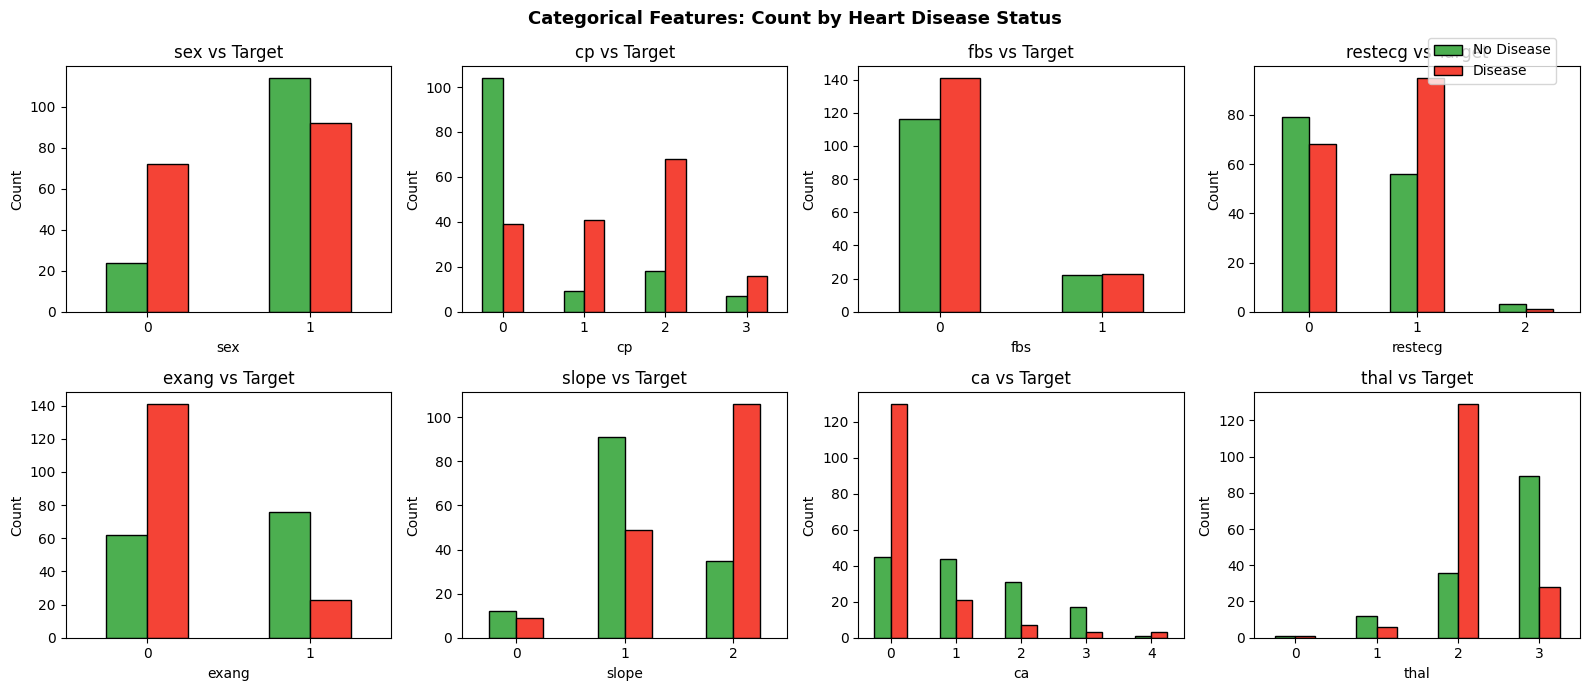

In [36]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    cross = pd.crosstab(df[col], df['target'])
    cross.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'], edgecolor='black', legend=False)
    ax.set_title(f'{col} vs Target')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylabel('Count')

fig.legend(['No Disease', 'Disease'], loc='upper right', bbox_to_anchor=(0.98, 0.95))
plt.suptitle('Categorical Features: Count by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

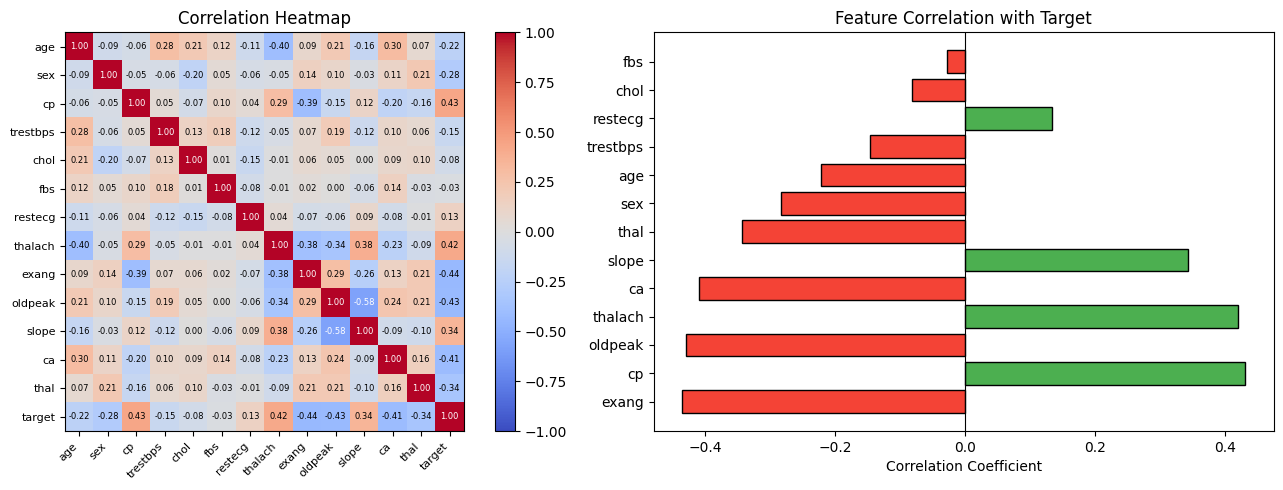

Top 5 most predictive features:
  exang: -0.436
  cp: 0.432
  oldpeak: -0.429
  thalach: 0.420
  ca: -0.409


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df.corr(numeric_only=True)
im = axes[0].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
axes[0].set_title('Correlation Heatmap')
plt.colorbar(im, ax=axes[0], fraction=0.046)

target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
colors = ['#F44336' if v < 0 else '#4CAF50' for v in target_corr.values]
axes[1].barh(range(len(target_corr)), target_corr.values, color=colors, edgecolor='black')
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

print("Top 5 most predictive features:")
for feat, val in target_corr.head(5).items():
    print(f"  {feat}: {val:.3f}")

### 3.6 Outlier Detection

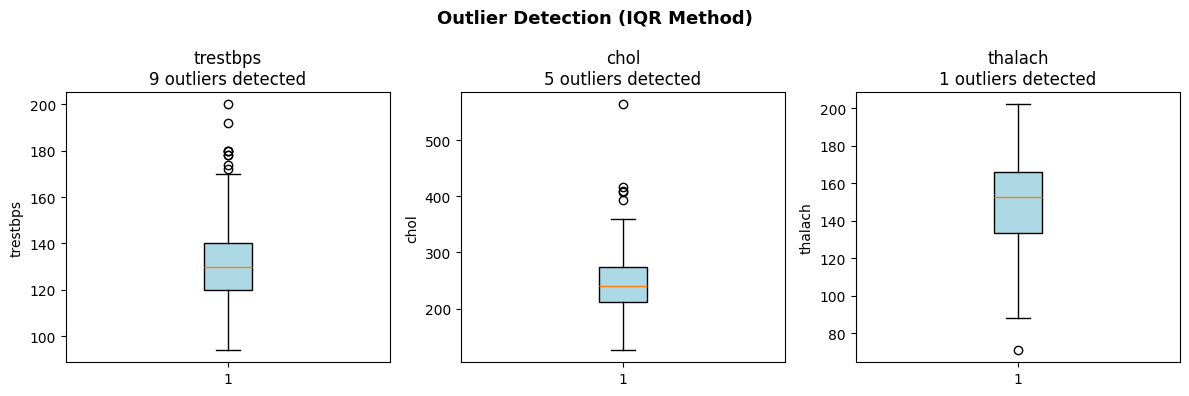

In [38]:
outlier_cols = ['trestbps', 'chol', 'thalach']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(outlier_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{col}\n{n_out} outliers detected')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [39]:
print(f"Before outlier removal: {df.shape[0]} rows")

for col in ['trestbps', 'chol', 'thalach']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

df = df.reset_index(drop=True)
print(f"After outlier removal: {df.shape[0]} rows")

Before outlier removal: 302 rows
After outlier removal: 287 rows


In [40]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train target distribution: {y_train.value_counts().to_dict()}")
print(f"Test  target distribution: {y_test.value_counts().to_dict()}")

Train: 229 rows | Test: 58 rows
Train target distribution: {1: 123, 0: 106}
Test  target distribution: {1: 35, 0: 23}


In [41]:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
encode_cols = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal', 'fbs']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), scale_cols),
    ('cat', OneHotEncoder(drop='first'), encode_cols)
], remainder='passthrough')

print(f"Preprocessor created.")
print(f"  Numerical columns ({len(scale_cols)}): {scale_cols}")
print(f"  Categorical columns ({len(encode_cols)}): {encode_cols}")

Preprocessor created.
  Numerical columns (5): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Categorical columns (8): ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal', 'fbs']


## 5. Model Comparison: Logistic Regression vs Random Forest

In [42]:
lr_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [43]:
rf_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]
print("Random Forest trained.")

Random Forest trained.


### 5.1 Metrics Comparison

In [44]:
models = {'Logistic Regression': (y_pred_lr, y_prob_lr, lr_pipe), 'Random Forest': (y_pred_rf, y_prob_rf, rf_pipe)}

results = []
for name, (y_pred, y_prob, pipe) in models.items():
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy').mean()
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_prob)
    results.append({
        'Model': name, 'Accuracy': acc, 'CV Accuracy': cv,
        'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC': auc
    })

df_results = pd.DataFrame(results).round(4)
print("\nModel Comparison:")
display(df_results)


Model Comparison:


,Model,Accuracy,CV Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.8966,0.8396,0.8897,0.8994,0.8934,0.9540
1,Random Forest,0.8448,0.8082,0.8396,0.8342,0.8366,0.9429


### 5.2 Accuracy Comparison Chart

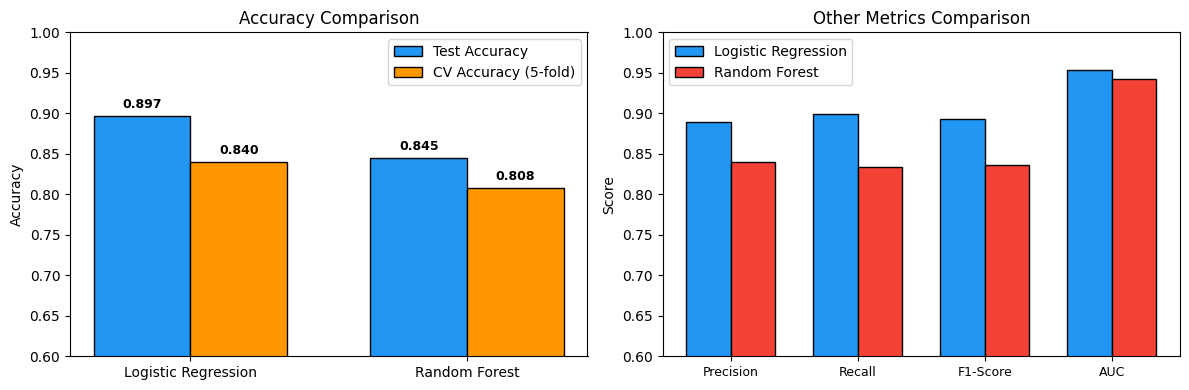

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(df_results))
w = 0.35
axes[0].bar(x - w/2, df_results['Accuracy'], w, label='Test Accuracy', color='#2196F3', edgecolor='black')
axes[0].bar(x + w/2, df_results['CV Accuracy'], w, label='CV Accuracy (5-fold)', color='#FF9800', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Model'], fontsize=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('Accuracy Comparison')
axes[0].legend()
for i, row in df_results.iterrows():
    axes[0].text(i - w/2, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", ha='center', fontweight='bold', fontsize=9)
    axes[0].text(i + w/2, row['CV Accuracy'] + 0.01, f"{row['CV Accuracy']:.3f}", ha='center', fontweight='bold', fontsize=9)

metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x_m = np.arange(len(metrics))
w_m = 0.35
for i, (_, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metrics]
    offset = -w_m/2 if i == 0 else w_m/2
    color = '#2196F3' if i == 0 else '#F44336'
    axes[1].bar(x_m + offset, vals, w_m, label=row['Model'], color=color, edgecolor='black')
axes[1].set_xticks(x_m)
axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.6, 1.0)
axes[1].set_title('Other Metrics Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix

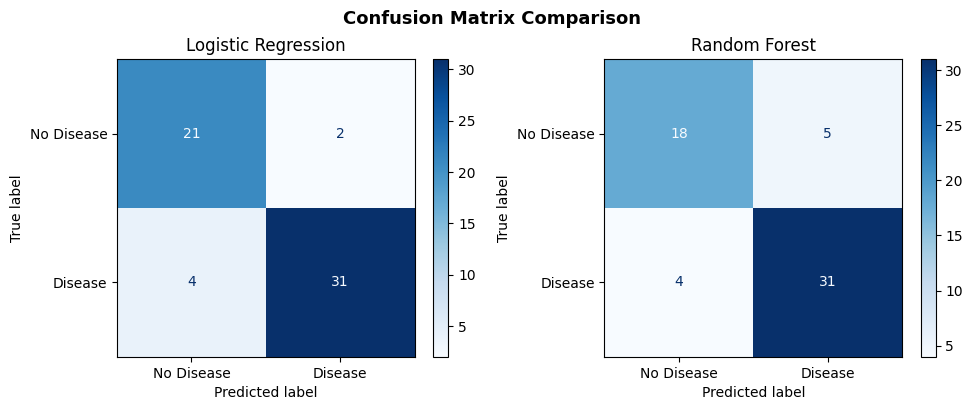

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, (y_pred, _, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'{name}')
plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 ROC Curve

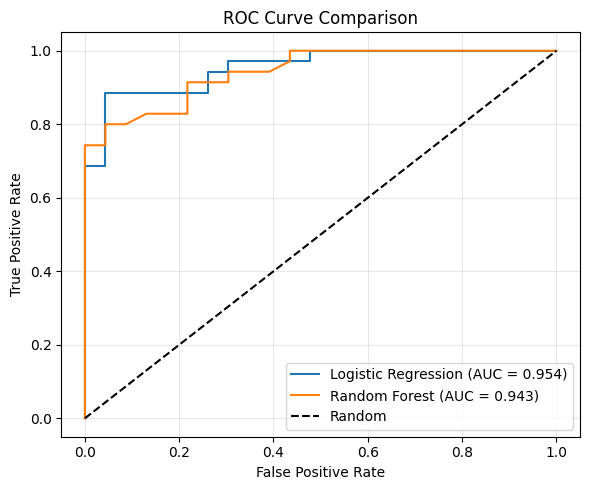

In [47]:
plt.figure(figsize=(6, 5))
for name, (_, y_prob, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Classification Reports

In [48]:
for name, (y_pred, _, _) in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))


Logistic Regression
                precision    recall  f1-score   support

No Disease (0)       0.84      0.91      0.88        23
   Disease (1)       0.94      0.89      0.91        35

      accuracy                           0.90        58
     macro avg       0.89      0.90      0.89        58
  weighted avg       0.90      0.90      0.90        58


Random Forest
                precision    recall  f1-score   support

No Disease (0)       0.82      0.78      0.80        23
   Disease (1)       0.86      0.89      0.87        35

      accuracy                           0.84        58
     macro avg       0.84      0.83      0.84        58
  weighted avg       0.84      0.84      0.84        58



### 5.6 Random Forest Feature Importance

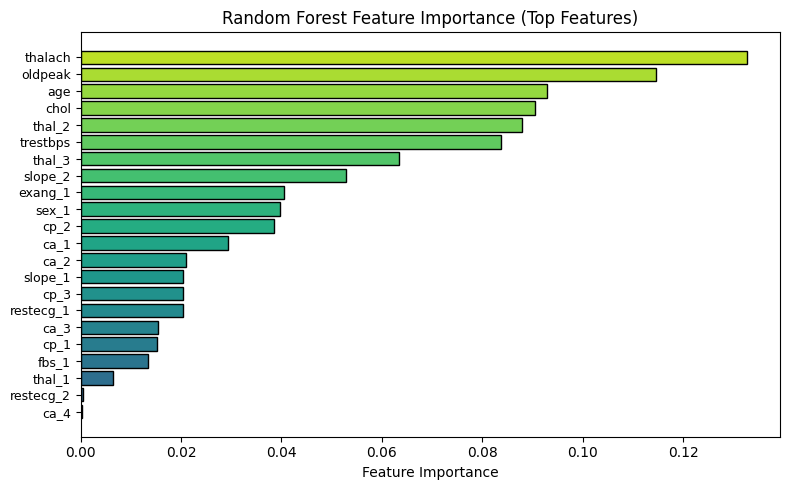

Top 5 most important features:
  thalach: 0.1326
  oldpeak: 0.1147
  age: 0.0929
  chol: 0.0904
  thal_2: 0.0879


In [49]:
rf_model = rf_pipe.named_steps['model']
ohe = rf_pipe.named_steps['preprocessing'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(encode_cols).tolist()
feature_names = scale_cols + cat_names

importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance)))
plt.barh(range(len(importance)), importance.values, color=colors[::-1], edgecolor='black')
plt.yticks(range(len(importance)), importance.index, fontsize=9)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Top Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for feat, imp in importance.head(5).items():
    print(f"  {feat}: {imp:.4f}")

## 6. Best Model Selection & Final Evaluation

In [50]:
best_idx = df_results['CV Accuracy'].idxmax()
best_name = df_results.loc[best_idx, 'Model']
best_model_name = 'lr' if 'Logistic' in best_name else 'rf'
best_pipe = models[best_name][2]
best_pred = models[best_name][0]
best_prob = models[best_name][1]

print(f"Best Model: {best_name}")
print(f"  Test Accuracy : {df_results.loc[best_idx, 'Accuracy']:.4f}")
print(f"  CV Accuracy   : {df_results.loc[best_idx, 'CV Accuracy']:.4f}")
print(f"  AUC           : {df_results.loc[best_idx, 'AUC']:.4f}")

Best Model: Logistic Regression
  Test Accuracy : 0.8966
  CV Accuracy   : 0.8396
  AUC           : 0.9540



Final Evaluation — Logistic Regression

                precision    recall  f1-score   support

No Disease (0)       0.84      0.91      0.88        23
   Disease (1)       0.94      0.89      0.91        35

      accuracy                           0.90        58
     macro avg       0.89      0.90      0.89        58
  weighted avg       0.90      0.90      0.90        58



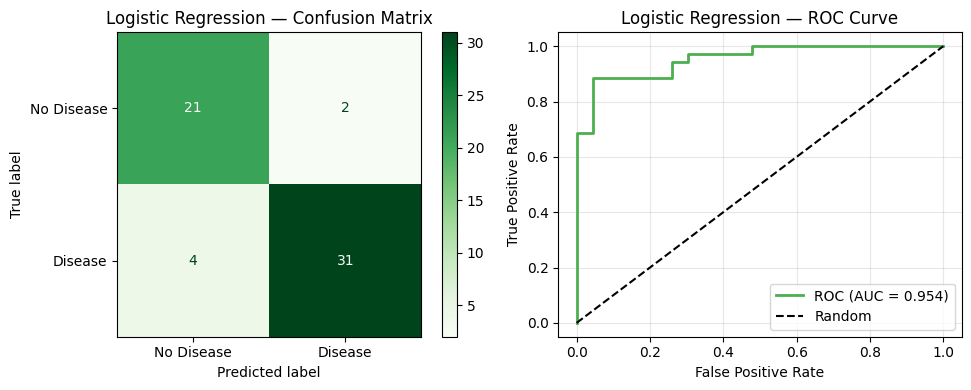

In [51]:
print(f"\nFinal Evaluation — {best_name}\n")
print(classification_report(y_test, best_pred, target_names=['No Disease (0)', 'Disease (1)']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title(f'{best_name} — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, best_prob)
auc = roc_auc_score(y_test, best_prob)
axes[1].plot(fpr, tpr, color='#4CAF50', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{best_name} — ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Export Model for REST API

In [52]:
import os
import json

os.makedirs('model', exist_ok=True)

full_pipeline_path = 'model/model_full.pkl'
model_path = 'model/heart_model.pkl'
scaler_path = 'model/scaler.pkl'
feature_list_path = 'model/feature_names.json'

joblib.dump(best_pipe, full_pipeline_path)
print(f"Full pipeline saved: {full_pipeline_path}")

preprocessor = best_pipe.named_steps['preprocessing']
model = best_pipe.named_steps['model']
joblib.dump(model, model_path)
joblib.dump(preprocessor, scaler_path)
print(f"Classifier saved: {model_path}")
print(f"Preprocessor (scaler) saved: {scaler_path}")

feature_names = {
    'scale_cols': scale_cols,
    'encode_cols': encode_cols,
    'model_name': best_name,
    'metrics': df_results.loc[best_idx].to_dict()
}
with open(feature_list_path, 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"Feature names saved: {feature_list_path}")

print(f"\nExport complete. Model: {best_name}")

Full pipeline saved: model/model_full.pkl
Classifier saved: model/heart_model.pkl
Preprocessor (scaler) saved: model/scaler.pkl
Feature names saved: model/feature_names.json

Export complete. Model: Logistic Regression


In [53]:
loaded_pipe = joblib.load(full_pipeline_path)
sample = X_test.iloc[:5]
pred = loaded_pipe.predict(sample)
prob = loaded_pipe.predict_proba(sample)[:, 1]

print("Test prediction with loaded model:")
for i, (p, pr) in enumerate(zip(pred, prob)):
    status = 'DISEASE' if p == 1 else 'NO DISEASE'
    print(f"  Sample {i+1}: {status} (probability: {pr:.3f})")

loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
sample_scaled = preprocessor.transform(sample)
pred2 = loaded_model.predict(sample_scaled)
print("\nTest prediction with separate model + scaler:")
for i, (p, pr) in enumerate(zip(pred2, loaded_model.predict_proba(sample_scaled)[:, 1])):
    status = 'DISEASE' if p == 1 else 'NO DISEASE'
    print(f"  Sample {i+1}: {status} (probability: {pr:.3f})")
print("\nBoth exports verified successfully.")

Test prediction with loaded model:
  Sample 1: NO DISEASE (probability: 0.014)
  Sample 2: NO DISEASE (probability: 0.419)
  Sample 3: NO DISEASE (probability: 0.306)
  Sample 4: NO DISEASE (probability: 0.100)
  Sample 5: NO DISEASE (probability: 0.157)

Test prediction with separate model + scaler:
  Sample 1: NO DISEASE (probability: 0.014)
  Sample 2: NO DISEASE (probability: 0.419)
  Sample 3: NO DISEASE (probability: 0.306)
  Sample 4: NO DISEASE (probability: 0.100)
  Sample 5: NO DISEASE (probability: 0.157)

Both exports verified successfully.


## Conclusion

**Best Model:** [Auto-filled after training]

**Files exported for REST API:**
- `model/model_full.pkl` — Full pipeline (preprocessor + classifier)
- `model/heart_model.pkl` — Classifier only (untuk Flask API)
- `model/scaler.pkl` — Preprocessor only (untuk Flask API)
- `model/feature_names.json` — Feature names and model info